In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, fbeta_score, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder

# Information About the Heart Failure Prediction Dataset

The Heart Failure Prediction dataset consolidates five independent heart disease datasets from the UCI Machine Learning Repository to create a comprehensive collection of 918 observations. Each patient profile is defined by 11 clinical features, including demographic data (age, sex), vital signs (resting blood pressure, cholesterol), and diagnostic results such as Resting ECG and ST slope. The target label is a binary indicator of heart disease presence. This dataset is particularly valuable for its diversity, though the synthesis of multiple sources requires robust preprocessing to handle varied clinical environments and ensure the Random Forest and Linear Regression models generalize effectively.

The inspiration for this project stems from a commitment as a biomedical engineer to address cardiovascular diseases (CVDs), which remain the leading cause of global mortality. With 17.9 million lives lost annually, the ability to transition from reactive treatment to proactive management is critical. While clinical diagnostics are often resource-intensive, the intersection of biomedical science and data science offers a path toward scalable, early detection tools that can identify high-risk individuals before a major cardiac event occurs.

This project was undertaken to bridge the gap between static clinical data and dynamic patient care. By utilizing this dataset as the backend for a full-stack application, the objective is to move beyond simple classification and create a functional ecosystem where users can assess their heart health and track physiological changes over time. This initiative aims to demonstrate how machine learning can power accessible, non-invasive screening tools, ultimately supporting both patients and healthcare professionals in the early management of cardiovascular risk.

# Data Collection and Processing

In [2]:
# Loading data csv file to Pandas DataFrame
heart_data = pd.read_csv('/content/data.csv')
heart_data.head() # Print first 5 rows of the dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
heart_data.tail() # Print last 5 rows of the dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


* **Age**: age of the patient [years]
* **Sex**: sex of the patient [M: Male, F: Female]
* **ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
* **RestingBP**: resting blood pressure [mm Hg]
* **Cholesterol**: serum cholesterol [mm/dl]
* **FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
* **RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
* **MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]
* **ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]
* **Oldpeak**: oldpeak = ST [Numeric value measured in depression]
* **ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
* **HeartDisease**: output class [1: heart disease, 0: Normal]

In [4]:
# Checking number of rows and columns in the dataset
heart_data.shape

(918, 12)

In [5]:
heart_data.info() # Getting general information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
# Check for any missing values
heart_data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
# Statistical measures about the data
heart_data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# Check distribution of Target Variable (distribution of Healthy - 0 vs Heart Disease - 1)
heart_data['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


## Binary Conversion
Converts binary categorical columns to 0 and 1 before using One Hot Encoding



---


Maps Sex to 1 (Male) and 0 (Female)

Maps Exercise Angina to 1 (Yes) and 0 (No)

In [9]:
heart_data['Sex'] = heart_data['Sex'].map({'M': 1, 'F': 0})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'Y': 1, 'N': 0})
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


## One Hot Encoding
Using One Hot Encoding on categorical columns (chest pain type, resting ECG, and ST slope). This creates equal-weight columns which treats all categories independently instead of using label encoding which assigns integers that can incorrectly imply a ranking or numerical relationship.

In [10]:
# Select categorical columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

# Create a OneHotEncoder instance
# sparse_output=False returns a dense NumPy array instead of a sparse matrix which only stores the location of non-zero values
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = ohe.fit_transform(heart_data[cat_cols])

# Create a DataFrame from the encoded features with appropriate column names
encoded_feature_names = ohe.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=heart_data.index)

# Drop the original categorical columns from X and concatenate the new encoded columns
heart_data_processed = pd.concat([heart_data.drop(columns=cat_cols), encoded_df], axis=1)

heart_data_processed.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180,0,156,0,1.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283,0,98,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214,0,108,1,1.5,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195,0,122,0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## Heatmap of Pearson Correlation Coefficients

Perform a pairwise analysis across the entire dataset to calculate and visualize the Pearson correlation coefficients for every possible pair of variables in a single heatmap.

The Pearson correlation coefficient is a statistical measure that quantifies the strength and direction of the *linear* relationship between two continuous variables.

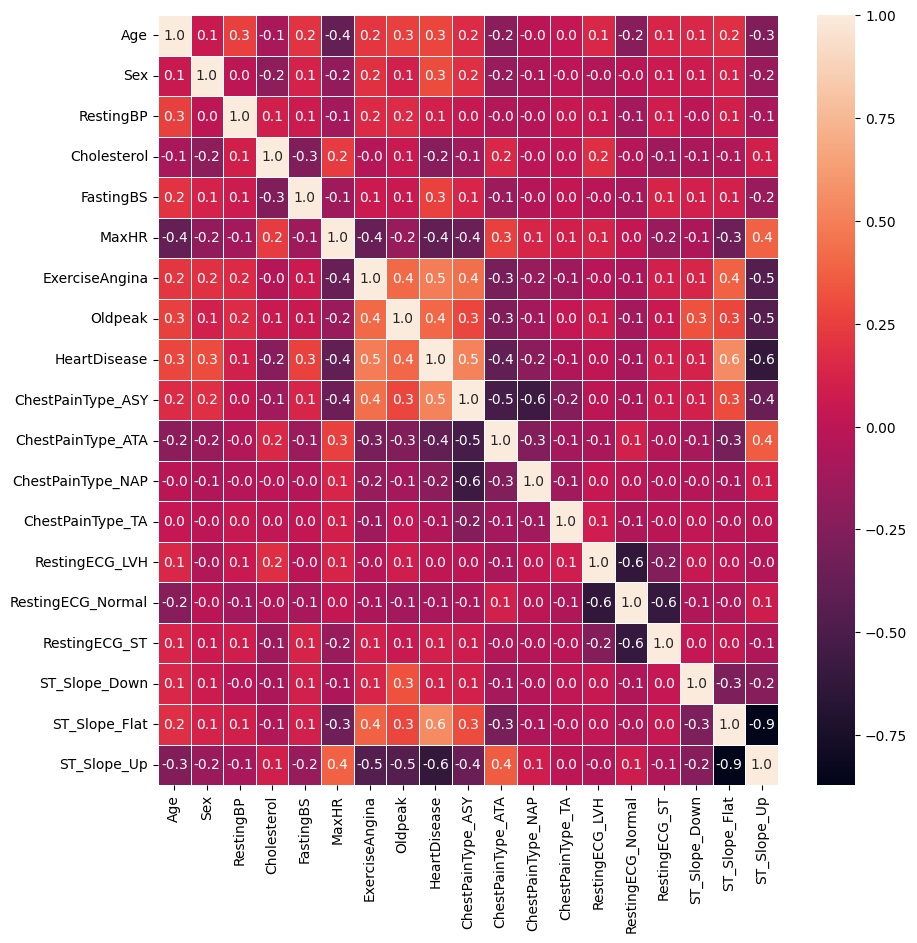

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heart_data_processed.corr(), annot=True, linewidths=0.5, fmt='.1f', ax=ax) # Show distribution of Pearson correlation coefficient for all columns, show annotations, round all values to 1 significant figure
plt.show()

This figure shows the Pearson Correlation Coefficients between two features ranging from -1 to +1
* **+1**: Indicates a perfect positive linear correlation (both variables increase/decrease together)
* **-1**: Indicates a perfect negative linear correlation (one varaible increase while the other decreases)
* **0**: No linear correlation between variables

### Key Predictors of Heart Disease
 Several features show a moderate to strong correlation with the presence of heart disease, serving as primary indicators for the model:
* **ST_Slope_Flat** (0.6): This is the strongest positive correlation, indicating that a flat ST segment during peak exercise is a significant predictor of heart disease.
* **ExerciseAngina** (0.5): Patients who experience angina (chest pain) during exercise show a notable positive correlation with the target variable.
* **Oldpeak** (0.4) & ChestPainType_ASY (0.5): Asymptomatic chest pain and higher values of ST depression (Oldpeak) are both positively associated with increased risk.
* **ST_Slope_Up** (-0.6): This shows a strong negative correlation, suggesting that an upward-sloping ST segment is a highly characteristic trait of healthy individuals in this dataset.

### Demographic and Physiological Insights
* **Age and Sex** (0.3): Both age and male sex (represented here after one-hot encoding) show positive correlations with heart disease, aligning with general medical literature that identifies these as established risk factors.
* **MaxHR** (-0.4): Maximum Heart Rate achieved shows a moderate negative correlation. Lower maximum heart rates during stress testing are often linked to cardiovascular impairment.
* **Cholesterol** (-0.2): Interestingly, cholesterol shows a weak negative correlation in this specific combined dataset, which may suggest the presence of outliers or the effect of medication (statins) among the sampled patients.

### Multi-collinearity Considerations
The matrix reveals strong relationships between certain independent variables that must be managed during the modeling phase:
* **ST_Slope_Flat vs. ST_Slope_Up** (-0.9): There is a very high negative correlation here, which is expected as these are mutually exclusive categories from the same original feature.
* **ExerciseAngina vs. Oldpeak** (0.4): These features are moderately correlated, as exercise-induced pain often coincides with measurable ST-segment depression.

### Implications for Modeling
* **For Linear Regression**: Features with very low correlation to the target (e.g., `RestingECG variants`) may provide limited predictive power in a linear context.
* **For Random Forest**: While this matrix focuses on linear relationships, the Random Forest classifier will be able to capture non-linear interactions between these variables (e.g., the combined effect of `Age` and `MaxHR`), likely resulting in higher predictive accuracy than linear methods alone.

## Violin Plots

Creating Violin plots to look for outliers in features with continous values (age, resting blood pressure, cholesterol, maximum heart rate, old peak).

Outliers will be replaced with the median value.

<Axes: ylabel='Age'>

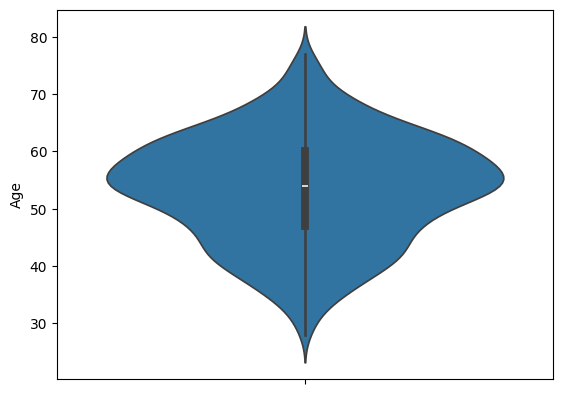

In [12]:
sns.violinplot(y='Age', data=heart_data)

The violin plot for `Age` indicates a relatively normal distribution centered around a median of approximately 54 years, with the majority of patients falling between 45 and 65. There are no visible outliers, as the data tails taper off smoothly within a biologically plausible range (roughly 28 to 78 years) without any isolated points beyond the whiskers. This suggests that the age feature is clean and well-suited for training models without further trimming.

<Axes: ylabel='RestingBP'>

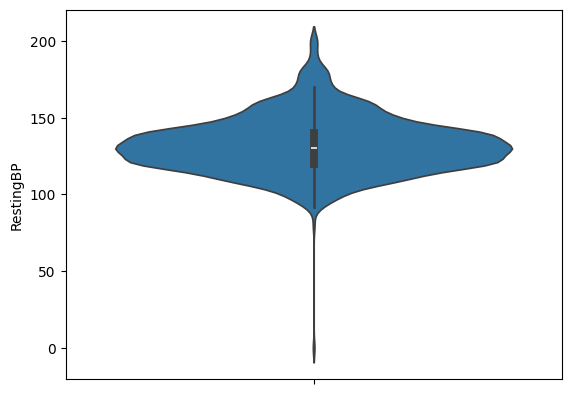

In [13]:
sns.violinplot(y='RestingBP', data=heart_data)

The violin plot for `RestingBP` (Resting Blood Pressure) reveals a significant low-value outlier near 0 mmHg, which is physiologically impossible for a living subject and likely represents missing or incorrectly recorded data. While the majority of the data is normally distributed around a healthy median of approximately 130 mmHg, there are also several high-value outliers extending toward 200 mmHg.


### Replacing Resting Blood Pressure outliers with median values

In [14]:
# Identify the row(s) with RestingBP = 0
zero_bp_rows = heart_data[heart_data['RestingBP'] == 0]
print(f"Number of rows with 0 RestingBP: {len(zero_bp_rows)}")

Number of rows with 0 RestingBP: 1


In [15]:
# Replace with Median
median_bp = heart_data[heart_data['RestingBP'] != 0]['RestingBP'].median()
heart_data['RestingBP'] = heart_data['RestingBP'].replace(0, median_bp)

Plotting the Violin Plot for `RestingBP` without the outlier

<Axes: ylabel='RestingBP'>

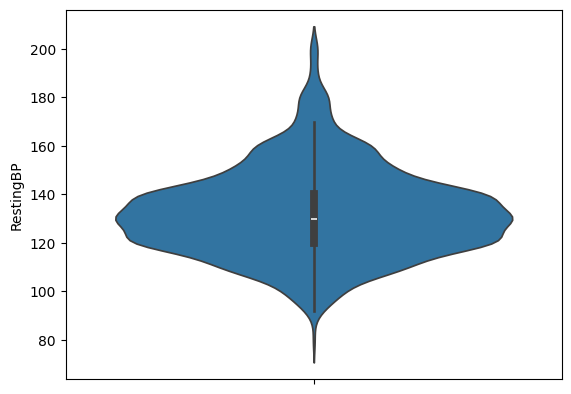

In [16]:
sns.violinplot(y='RestingBP', data=heart_data)

<Axes: ylabel='Cholesterol'>

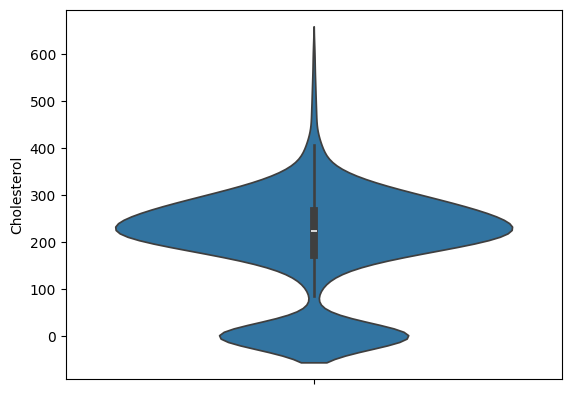

In [31]:
sns.violinplot(y='Cholesterol', data=heart_data)

The violin plot for `Cholesterol` displays a heavy concentration of data around the 200–250 mg/dl range, but it also reveals significant data quality issues. A distinct cluster of outliers at 0 mg/dl indicates a large number of missing values that are physiologically impossible and must be addressed through imputation or removal. Additionally, there are several extreme high-value outliers extending toward 600 mg/dl. However these are clinically possible and are vital for capturing the full range of cardiovascular risk profiles.


### Replacing Cholesterol outliers with median values

In [17]:
# Identify the row(s) with Cholesterol = 0
zero_bp_rows = heart_data[heart_data['Cholesterol'] == 0]
print(f"Number of rows with 0 Cholesterol: {len(zero_bp_rows)}")

Number of rows with 0 Cholesterol: 172


In [19]:
# Replace with Median
median_chol = heart_data[heart_data['Cholesterol'] != 0]['Cholesterol'].median()
heart_data['Cholesterol'] = heart_data['Cholesterol'].replace(0, median_chol)

Plotting the Violin Plot for `Cholesterol` without the outlier

<Axes: ylabel='Cholesterol'>

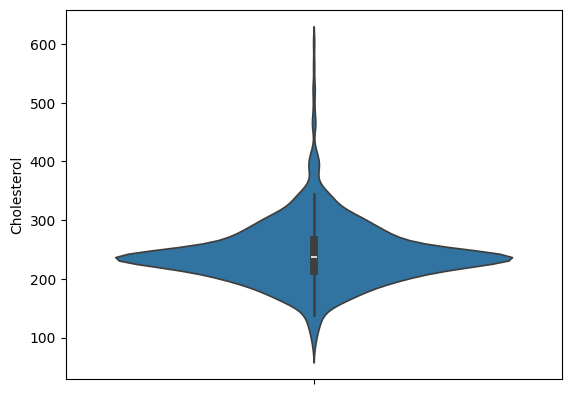

In [20]:
sns.violinplot(y='Cholesterol', data=heart_data)

<Axes: ylabel='MaxHR'>

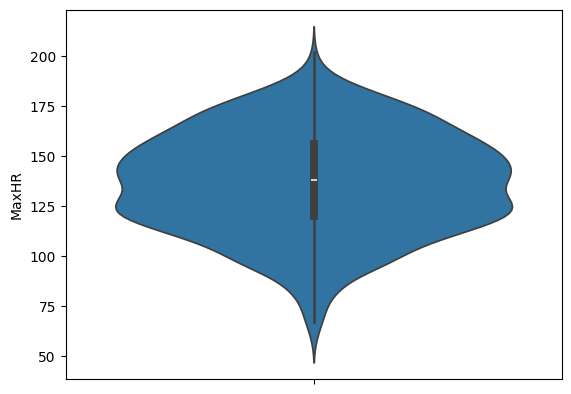

In [32]:
sns.violinplot(y='MaxHR', data=heart_data)

The violin plot for `MaxHR` (Maximum Heart Rate) displays a well-distributed range of values centered around a median of approximately 140 bpm, with most data points falling between 120 and 160 bpm. There are no significant outliers, as the distribution tapers off naturally at both ends—reaching a peak near 200 bpm and a lower limit around 60 bpm—which are both physiologically normal limits for a clinical population during exercise. This clean, relatively symmetric distribution suggests that the feature is ready for modeling without the need for additional cleaning or imputation.


<Axes: ylabel='Oldpeak'>

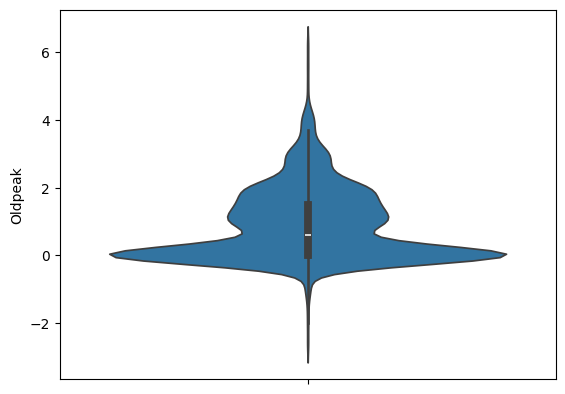

In [67]:
sns.violinplot(y='Oldpeak', data=heart_data)

The violin plot for `Oldpeak` shows a heavily right-skewed distribution, with a massive concentration of data points at or near 0.0, representing patients with no ST-segment depression. While there are several high-value outliers extending toward 6.2, these are physiologically significant and likely correspond to severe ischemia, making them vital indicators for heart disease prediction. The small negative tail (values below 0) is likely a byproduct of the plot's density estimation rather than actual data, so the feature should be kept as-is to capture the full spectrum of cardiac risk.

# Splitting Features and Target

In [21]:
X = heart_data_processed.drop(columns='HeartDisease', axis=1) # Store features in X
Y = heart_data_processed['HeartDisease'] # Store target variable in Y

In [22]:
X.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180,0,156,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283,0,98,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214,0,108,1,1.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195,0,122,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Includes all columns except the target column ('Heart Disease')

In [23]:
Y.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


# Splitting the Data into Training and Test Data

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2) # 80/20 split between training and test data, stratify = Y --> even distribution between Heart Disease (1) and Healthy (0)

In [25]:
# Checking 80/20 split for training and test data
print(X.shape, X_train.shape, X_test.shape)
print(Y.shape, Y_train.shape, Y_test.shape)

(918, 18) (734, 18) (184, 18)
(918,) (734,) (184,)


# Model Training

## Logistic Regression

In this project, Logistic Regression is used to establish an optimal **decision boundary** that separates patients with heart disease from those without. This model calculates a **weighted sum** of the 11 clinical features (e.g., `Oldpeak`, `Age`) and passes the result through a **Sigmoid function** to output a probability between 0 and 1.

To find the "best fit," the model uses **Maximum Likelihood Estimation (MLE)**. This iterative process adjusts the weight of each feature to maximize the probability that the model’s predictions match the actual clinical labels in the dataset. Geometrically, the "best fit" is the specific boundary in the 11-dimensional feature space that most accurately partitions the two classes. Features with large positive coefficients (weights) push a patient across this boundary toward a heart disease diagnosis, while negative coefficients pull them toward the "normal" category.

In [51]:
lr_model = LogisticRegression()

In [52]:
# Training the Logistic Regression model with Training Data
lr_model.fit(X_train, Y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Random Forest

In this project, the **Random Forest Classifier** serves as a robust, non-linear alternative to Logistic Regression. It is an **ensemble learning** method that constructs a multitude of individual **Decision Trees** during training and outputs the class that is the majority "vote" of those trees.

To find the "best fit," the model uses a process called **Bootstrap Aggregating (Bagging)**, where each tree is trained on a random subset of both the patient data and the 11 clinical features. Instead of a single decision boundary, each tree makes a series of binary "if-then" splits (e.g., *Is MaxHR < 140?*) designed to maximize **Information Gain** and reduce class impurity. This ensemble approach prevents **overfitting** and allows the model to capture complex, non-linear interactions between risk factors that a simple linear model might miss.

In [53]:
rf_model = RandomForestClassifier(max_depth=5)
rf_model.fit(X_train, Y_train)


RandomForestClassifier(max_depth=5)

# Model Evaluation

## Accuracy Score
Evaluating the accuracy score on the training and test data

### Logistic Regression

Evaluating the accuracy score on the training data

In [54]:
lr_X_train_prediction = lr_model.predict(X_train)
training_data_accuracy = accuracy_score(lr_X_train_prediction, Y_train)
print(f'Accuracy on Training data: {training_data_accuracy}')

Accuracy on Training data: 0.8692098092643051


Evaluating the accuracy score on the test data

In [55]:
lr_X_test_prediction = lr_model.predict(X_test)
print(f"balanced-accuracy: {balanced_accuracy_score(Y_test, lr_X_test_prediction)}")
print(f"accuracy: {accuracy_score(Y_test, lr_X_test_prediction)}")
print(f"precision: {precision_score(Y_test, lr_X_test_prediction)}")
print(f"recall: {recall_score(Y_test, lr_X_test_prediction)}")
print(f"f2: {fbeta_score(Y_test, lr_X_test_prediction, beta=2)}")

balanced-accuracy: 0.8754184600669536
accuracy: 0.8804347826086957
precision: 0.8703703703703703
recall: 0.9215686274509803
f2: 0.9108527131782945


### Random Forest

Evaluating the accuracy score on the training data

In [56]:
rf_X_train_prediction = rf_model.predict(X_train)
training_data_accuracy = accuracy_score(rf_X_train_prediction, Y_train)
print(f'Accuracy on Training data: {training_data_accuracy}')

Accuracy on Training data: 0.9005449591280654


Evaluating the accuracy score on the test data

In [57]:
rf_X_test_prediction = rf_model.predict(X_test)
print(f"balanced-accuracy: {balanced_accuracy_score(Y_test, rf_X_test_prediction)}")
print(f"accuracy: {accuracy_score(Y_test, rf_X_test_prediction)}")
print(f"precision: {precision_score(Y_test, rf_X_test_prediction)}")
print(f"recall: {recall_score(Y_test, rf_X_test_prediction)}")
print(f"f2: {fbeta_score(Y_test, rf_X_test_prediction, beta=2)}")

balanced-accuracy: 0.8913199426111909
accuracy: 0.8967391304347826
precision: 0.8807339449541285
recall: 0.9411764705882353
f2: 0.9284332688588007


The **Random Forest** model outperforms Logistic Regression across all metrics, notably achieving a higher **recall** and **F2-score**. In a medical context like heart disease prediction, these metrics are critical as they prioritize minimizing **false negatives** (missed cases).

While both models demonstrate strong predictive power, Random Forest's superior balanced accuracy suggests it handles potential class imbalances more effectively, making it the more robust choice for clinical reliability.

## Confusion Matrix
Evaluating True Positives, True Negatives, False Positives, and False Negatives

### Logistic Regression

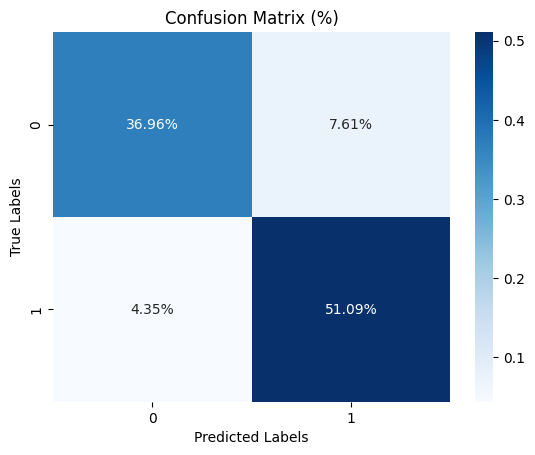

In [80]:
cm = confusion_matrix(Y_test, lr_X_test_prediction)
sns.heatmap(cm/np.sum(cm), annot=True, fmt=".2%", cmap='Blues') # Displays the Confusion Matrix as a heatmap in percentages

# Labeling the axes
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (%)')

plt.show()

### Random Forest

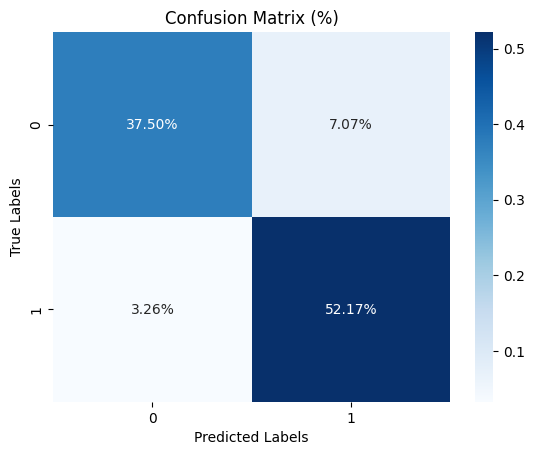

In [81]:
cm = confusion_matrix(Y_test, rf_X_test_prediction)
sns.heatmap(cm/np.sum(cm), annot=True, fmt=".2%", cmap='Blues') # Displays the Confusion Matrix as a heatmap in percentages

# Labeling the axes
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (%)')

plt.show()

The **Random Forest** model demonstrates superior overall performance compared to the Logistic Regression model as seen by the slightly higher percentages of True Positive and True Negatives and slightly lower percentages of False Positives and False Negatives. This is expected as Random Forest, an ensemble method, is better equipped to capture non-linear relationships and intricate patterns within the data.

The Random Forest model shows a stronger ability to correctly identify positive instances (Heart Disease). Its **Recall** is significantly higher than the Logistic Regression model's, as it misses fewer actual positive cases.

While the Random Forest reduced the rate of "missed" Heart Disease instances in the Logistic Regression model, both models exhibit similar performance in terms of False Positives (predicting Heart Disease when the patient is Healthy). However the higher sensitivity is preferred as misses in Heart Disease are more detrimental to pateint health than False Alarms.

While the Logistic Regression model is slightly less accurate, it offers higher interpretability and consistency, which may be preferable if the goal is to understand the specific impact of individual features. However, for pure predictive power, Random Forest is the more robust choice in this scenario.

## ROC Curve
Evaluate the tradeoff between sensitivity and specificity by mapping the True Positive Rate against the False Positive Rate. This shows how well the models seperate the between the two classes (Healthy vs Heart Disease).

The AUC (Area Under the ROC Curve) provides a performance metric for binary classification. Ranging from 0 to 1, an AUC of 0.5 indicates random guessing while 1.0 represent perfect classification. Generally an AUC above 0.8 is considered good while an AUC above 0.9 is excellent.

### Logistic Regression

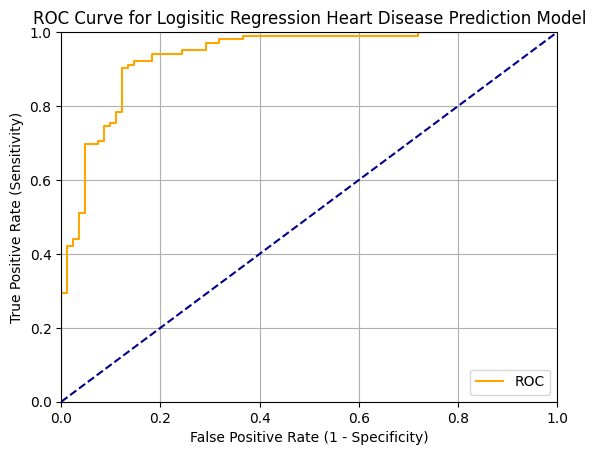

In [69]:
y_pred_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='orange', label='ROC')
ax.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Logisitic Regression Heart Disease Prediction Model')
ax.legend()
plt.grid(True)
plt.show()

In [70]:
lr_auc = auc(fpr, tpr)
print(f'Area Under the Curve (AUC): {lr_auc}')

Area Under the Curve (AUC): 0.9355571496891439


### Random Forest

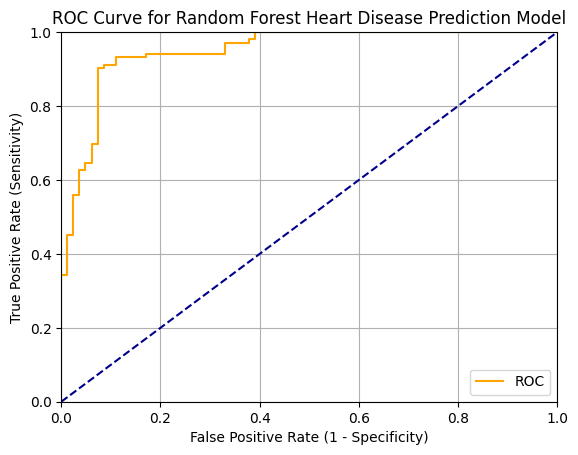

In [71]:
y_pred_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='orange', label='ROC')
ax.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Random Forest Heart Disease Prediction Model')
ax.legend()
plt.grid(True)
plt.show()

In [72]:
lr_auc = auc(fpr, tpr)
print(f'Area Under the Curve (AUC): {lr_auc}')

Area Under the Curve (AUC): 0.9488283118125298


Both models demonstrate **outstanding** diagnostic performance, exceeding the 0.90 threshold for excellence.

However, the **Random Forest** model achieves a higher AUC, indicating superior discriminatory power. It is more effective at correctly ranking positive cases (Heart Disease present) above negative cases compared to the Logistic Regression model.

As seen above, the ROC curve for the Random Forest model touches the top-left corner of the plot more closely. This visual proximity to the "ideal" classifier represents a better trade-off between **Sensitivity** (identifying sick patients) and **Specificity** (avoiding false alarms).

While Logistic Regression provides a strong baseline, the Random Forest’s ensemble approach better captures the non-linear complexities and interactions inherent in clinical heart disease data.



## Conclusion
The Random Forest model is the better-performing classifier for this dataset. It achieves a higher overall accuracy and AUC value, and specifically excels at minimizing False Negatives, making it more reliable for detecting Heart Disease.

# Predictive System

In [82]:
# Using the data from the 2nd patient to test predictive system
input_data = (49, 0,	160,	180,	0,	156,	0,	1.0,	0.0,	0.0,	1.0,	0.0,	0.0,	1.0,	0.0,	0.0,	1.0,	0.0)

# Change input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape the numpy array to predict for only one instance. (1, -1) structures the data as a single, horizantal row no matter the dimension
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = rf_model.predict(input_data_reshaped)
print(f'Prediction: {prediction}')

if prediction[0] == 0:
  print('This Patient does not have Heart Disease')
else:
  print('This Patient has Heart Disease')

Prediction: [0]
This Patient does not have Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# References
fedesoriano. (September 2021). Heart Failure Prediction Dataset. Retrieved March 2026 from https://www.kaggle.com/fedesoriano/heart-failure-prediction.